In [1]:
import os
from datetime import datetime
from sys import exit
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from re import X

from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F

os.makedirs("models", exist_ok=True)
os.makedirs("ensemble_models", exist_ok=True)

def set_all_seeds(seed):
    np.random.seed(seed)
    print(f"Random Seed: {seed}")
    random.seed(seed)
    torch.manual_seed(seed)

seed = 0
set_all_seeds(seed)



Random Seed: 0


In [2]:

df = pd.read_csv(f"BTCUSDT-15m-data.csv")
print(df.head())

             timestamp      open_time     open     high      low    close  \
0  2017-08-17 04:00:00  1502942400000  4261.48  4280.56  4261.48  4261.48   
1  2017-08-17 04:15:00  1502943300000  4261.48  4270.41  4261.32  4261.45   
2  2017-08-17 04:30:00  1502944200000  4280.00  4310.07  4267.99  4310.07   
3  2017-08-17 04:45:00  1502945100000  4310.07  4313.62  4291.37  4308.83   
4  2017-08-17 05:00:00  1502946000000  4308.83  4328.69  4304.31  4304.31   

      volume     close_time      quote_av  trades  tb_base_av   tb_quote_av  \
0   2.189061  1502943299999   9333.620962       9    0.489061   2089.104962   
1   9.119865  1502944199999  38891.133046      40    3.447113  14703.934995   
2  21.923552  1502945099999  94080.917568      58   20.421317  87620.977876   
3  13.948531  1502945999999  60060.466816      64   10.803012  46538.460109   
4   5.101153  1502946899999  22006.533111      44    3.496635  15093.783057   

   ignore  
0       0  
1       0  
2       0  
3       0  
4 

In [3]:
df.count()

,0
timestamp,276000
open_time,276000
open,276000
high,276000
low,276000
close,276000
volume,276000
close_time,276000
quote_av,276000
trades,276000


In [4]:
df.tail()

,timestamp,open_time,open,high,low,close,volume,close_time,quote_av,trades,tb_base_av,tb_quote_av,ignore
275995,2025-07-07 00:00:00,1751846400000,109203.85,109273.07,109103.19,109273.06,56.48447,1751847299999,6.166301e+06,26415,26.22332,2.862917e+06,0
275996,2025-07-07 00:15:00,1751847300000,109273.07,109288.02,108972.69,109004.81,75.36437,1751848199999,8.220317e+06,24191,33.56157,3.660548e+06,0
275997,2025-07-07 00:30:00,1751848200000,109004.81,109037.82,108829.17,108847.16,76.72080,1751849099999,8.357724e+06,21368,33.08997,3.605029e+06,0
275998,2025-07-07 00:45:00,1751849100000,108847.17,108922.00,108800.01,108823.07,45.06548,1751849999999,4.906468e+06,15579,22.76836,2.478881e+06,0
275999,2025-07-07 01:00:00,1751850000000,108823.07,108823.08,108679.75,108767.01,75.71845,1751850899999,8.232864e+06,22928,38.85713,4.224608e+06,0


In [5]:
print(df.isnull())
print(f'Counts how many missing values there are in each column: {df.isnull().sum()}')
print(f'Total missing values: {df.isnull().sum().sum()}')

        timestamp  open_time   open   high    low  close  volume  close_time  \
0           False      False  False  False  False  False   False       False   
1           False      False  False  False  False  False   False       False   
2           False      False  False  False  False  False   False       False   
3           False      False  False  False  False  False   False       False   
4           False      False  False  False  False  False   False       False   
...           ...        ...    ...    ...    ...    ...     ...         ...   
275995      False      False  False  False  False  False   False       False   
275996      False      False  False  False  False  False   False       False   
275997      False      False  False  False  False  False   False       False   
275998      False      False  False  False  False  False   False       False   
275999      False      False  False  False  False  False   False       False   

        quote_av  trades  tb_base_av  t

#Training Phase

Splitting data to train/test sets

Practice same pattersn multiple times

Have access to answer key

problems known:
Overfitting
Underfitting

#Testing Phase

Face new Patterns

No access to asnwer key


In [6]:
df[['open', 'high', 'low', 'close', 'volume']].head()

,open,high,low,close,volume
0,4261.48,4280.56,4261.48,4261.48,2.189061
1,4261.48,4270.41,4261.32,4261.45,9.119865
2,4280.00,4310.07,4267.99,4310.07,21.923552
3,4310.07,4313.62,4291.37,4308.83,13.948531
4,4308.83,4328.69,4304.31,4304.31,5.101153


In [7]:

df['open'].dtypes

dtype('float64')

In [8]:
df['open_time'].diff().dropna().value_counts().head()

,count
open_time,
900000.0,275966
4500000.0,5
8100000.0,3
1800000.0,2
7200000.0,2


In [9]:
# # what is a feature:
# # a Mesurable piece of information that describe the data
# # help the model to recognize patterns

# #always pay attention to the shape of the data

# def compute_moving_average(prices, window):
#     values = np.full(len(prices), np.nan, dtype=np.float64)
#     for i in range(window - 1, len(prices)):
#         values[i] = prices[i - window + 1:i + 1].mean()  # FIX: mean, not max
#     return values

# def compute_moving_std(prices, window):
#     values = np.full(len(prices), np.nan, dtype=np.float64)
#     for i in range(window - 1, len(prices)):
#         values[i] = prices[i - window + 1:i + 1].std()
#     return values

# def build_feature(opens, highs, lows, closes, volumes, train_scalers=None):

#     #EPSILON
#     eps = 1e-12

#     #build features
#     #candle shape features (normalized)
#     feature1 = (closes - opens) / (opens + eps)
#     feature2 = (highs - opens) / (opens + eps) # how much price rose above the open
#     feature3 = (highs - closes) / (closes + eps) # how far the close was below the high
#     feature4 = (lows - opens) / (opens + eps) # how much price fell below the open

#     # “How far the low was below the close” (lower wick strength)
#     feature5 = (closes - lows) / (closes + eps)

#     feature6 = (highs - lows) / (opens + eps) # the day's volatility range relative to open
#     feature7 = (highs - lows) / (closes + eps) # the day's volatility range relative to close

#     # Volume: heavy-tailed -> stabilize
#     feature8 = np.log1p(volumes)

#     # MA deviation + volatility
#     close_ma_5 = compute_moving_average(closes, 5)
#     feature9 = (closes - close_ma_5) / (close_ma_5 + eps)

#     feature10 = compute_moving_std(closes, 5) / (close_ma_5 + eps)

#     # Stack features
#     features = [
#       feature1, feature2,
#       feature3, feature4,
#       feature5, feature6,
#       feature7, feature8,
#       feature9, feature10
#     ]

#     # Drop rows with NaN (from rolling features)
#     feat_mat = np.stack(features, axis=-1)  # (m, 10)
#     valid_mask = ~np.isnan(feat_mat).any(axis=1)

#     #feature matrix shape(m, 10) 10 = n features
#     feat_mat = feat_mat[valid_mask]

#     num_features = feat_mat.shape[1]

#     scaled_fts = []

#     if train_scalers is None:
#       train_scalers = [MaxAbsScaler() for _ in range(num_features)]
#       is_train = True
#     else:
#       is_train = False

#     scaled_cols = []
#     for i in range(num_features):
#         col = feat_mat[:, i].reshape(-1, 1)
#         scaler = train_scalers[i]
#         if is_train:
#             col_s = scaler.fit_transform(col)
#         else:
#             col_s = scaler.transform(col)
#         scaled_cols.append(col_s.reshape(-1))

#     scaled_features = np.stack(scaled_cols, axis=-1)  # (m_valid, 10)
#     return scaled_features, num_features, train_scalers, valid_mask

In [10]:
# # what is a feature:
# # a Mesurable piece of information that describe the data
# # help the model to recognize patterns

# #always pay attention to the shape of the data.

# Keep your 10 + add:

# ret_4h, ret_12h, ret_24h

# trend_20_100

# atr_pct

# vol_ratio

# vol_z

def compute_moving_average(prices, window):
    values = np.full(len(prices), np.nan, dtype=np.float64)
    for i in range(window - 1, len(prices)):
        values[i] = prices[i - window + 1:i + 1].mean()  # FIX: mean, not max
    return values

def compute_moving_std(prices, window):
    values = np.full(len(prices), np.nan, dtype=np.float64)
    for i in range(window - 1, len(prices)):
        values[i] = prices[i - window + 1:i + 1].std()
    return values

def rolling_std(x, window):
    values = np.full(len(x), np.nan, dtype=np.float64)
    for i in range(window - 1, len(x)):
        values[i] = x[i - window + 1:i + 1].std()
    return values

def atr(highs, lows, closes, window):
    tr = np.full(len(closes), np.nan, dtype=np.float64)
    tr[0] = highs[0] - lows[0]
    for i in range(1, len(closes)):
        tr[i] = max(
            highs[i] - lows[i],
            abs(highs[i] - closes[i-1]),
            abs(lows[i]  - closes[i-1]),
        )
    # ATR = moving average of TR
    return compute_moving_average(tr, window)

def build_feature(opens, highs, lows, closes, volumes, train_scalers=None):

    # EPSILON: avoid division by zero
    eps = 1e-12

    # --- helpers (minimal, numpy-only) ---
    def ema(prices, span):
        # Exponential moving average (EMA)
        out = np.full(len(prices), np.nan, dtype=np.float64)
        alpha = 2.0 / (span + 1.0)
        s = np.nan
        for i, p in enumerate(prices):
            if np.isnan(s):
                s = p
            else:
                s = alpha * p + (1 - alpha) * s
            out[i] = s
        return out

    # -------------------------
    # 1) Candle shape features
    # -------------------------
    #candle shape features (normalized)

    feature1 = (closes - opens) / (opens + eps)
    feature2 = (highs - opens) / (opens + eps)
    feature3 = (highs - closes) / (closes + eps)
    feature4 = (lows - opens) / (opens + eps)
    feature5 = (closes - lows) / (closes + eps)           # lower wick strength
    feature6 = (highs - lows) / (opens + eps)
    feature7 = (highs - lows) / (closes + eps)

    # -------------------------
    # 2) Volume (stabilized)
    # -------------------------
    log_vol = np.log1p(volumes)
    feature8 = log_vol

    # -------------------------
    # 3) Short MA deviation + vol (keep your current)
    # -------------------------
    close_ma_5 = compute_moving_average(closes, 5)
    feature9  = (closes - close_ma_5) / (close_ma_5 + eps)
    feature10 = compute_moving_std(closes, 5) / (close_ma_5 + eps)

    # ==========================================================
    # 4) NEW: multi-scale returns (good for horizon=48 / 12 hours)
    # ==========================================================
    # 15m bars: 1h=4, 4h=16, 12h=48, 24h=96
    ret_4h  = np.full(len(closes), np.nan, dtype=np.float64)
    ret_12h = np.full(len(closes), np.nan, dtype=np.float64)
    ret_24h = np.full(len(closes), np.nan, dtype=np.float64)

    ret_4h[16:]   = np.log((closes[16:] + eps) / (closes[:-16] + eps))
    ret_12h[48:]  = np.log((closes[48:] + eps) / (closes[:-48] + eps))
    ret_24h[96:]  = np.log((closes[96:] + eps) / (closes[:-96] + eps))

    feature11 = ret_4h
    feature12 = ret_12h
    feature13 = ret_24h

    # ==========================================
    # 5) NEW: trend regime (EMA distance, normal)
    # ==========================================
    ema_20  = ema(closes, 20)
    ema_100 = ema(closes, 100)

    # trend slope proxy / regime: positive -> bullish regime
    trend_20_100 = (ema_20 - ema_100) / (ema_100 + eps)
    price_vs_ema20 = (closes - ema_20) / (ema_20 + eps)

    feature14 = trend_20_100
    feature15 = price_vs_ema20

    # ==========================================
    # 6) NEW: relative volume (volume "surprise")
    # ==========================================
    vol_ma_96 = compute_moving_average(log_vol, 96)      # 24h baseline
    vol_z = (log_vol - vol_ma_96)                        # deviation from baseline

    feature16 = vol_z

    # =========================
    # Volatility regime features
    # =========================

    # ATR(14): Average True Range over 14 bars (14 * 15m = 3.5 hours)
    # True Range captures gap + intrabar volatility:
    #   TR = max(high-low, |high-prev_close|, |low-prev_close|)
    # ATR is the moving average of TR -> a smoother volatility measure.
    atr_14 = atr(highs, lows, closes, 14)

    # Feature17: ATR as a % of price (scale-invariant volatility)
    # High atr_pct = market is "wild" (bigger swings relative to price)
    # Low atr_pct  = market is calmer (smaller swings relative to price)
    feature17 = atr_14 / (closes + eps)

    # Log price series (log makes returns/vol more stable and additive)
    log_close = np.log(closes + eps)

    # Rolling volatility (std) on log price:
    # window 16 bars = 4 hours
    # window 96 bars = 24 hours
    vol_short = rolling_std(log_close, 16)   # short-term vol (4h)
    vol_long  = rolling_std(log_close, 96)   # long-term vol  (24h)

    # Feature18: Volatility ratio = short vol / long vol
    # > 1  => volatility expanding (often breakout/trend regime)
    # < 1  => volatility compressing (often chop / pre-breakout)
    feature18 = vol_short / (vol_long + eps)

    # Stack features (now more than 10)
    features = [
      feature1, feature2,
      feature3, feature4,
      feature5, feature6,
      feature7, feature8,
      feature9, feature10,
      feature11, feature12,
      feature13, feature14,
      feature15, feature16,
      feature17, feature18
    ]

    # Drop rows with NaN (from rolling/EMA/returns)
    feat_mat = np.stack(features, axis=-1)  # (m, num_features)
    valid_mask = ~np.isnan(feat_mat).any(axis=1)
    feat_mat = feat_mat[valid_mask]

    num_features = feat_mat.shape[1]

    # --- scaling (same as your code) ---
    if train_scalers is None:
        train_scalers = [MaxAbsScaler() for _ in range(num_features)]
        is_train = True
    else:
        is_train = False

    scaled_cols = []
    for i in range(num_features):
        col = feat_mat[:, i].reshape(-1, 1)
        scaler = train_scalers[i]
        if is_train:
            col_s = scaler.fit_transform(col)
        else:
            col_s = scaler.transform(col)
        scaled_cols.append(col_s.reshape(-1))

    scaled_features = np.stack(scaled_cols, axis=-1)
    return scaled_features, num_features, train_scalers, valid_mask

In [11]:
# # This list will store each feature AFTER scaling
# # Each element will be a 1D array (one column / one feature)
# scaled_cols = []

# # Loop through each feature (column-wise scaling)
# for i in range(num_features):

#     # Extract ONE feature column from the feature matrix
#     # feat_mat shape: (num_rows, num_features)
#     # col shape becomes: (num_rows, 1)
#     # We reshape because sklearn scalers expect 2D input
#     col = feat_mat[:, i].reshape(-1, 1)

#     # Get the scaler corresponding to this feature
#     # Each feature has its own scaler to avoid mixing distributions
#     scaler = train_scalers[i]

#     if is_train:
#         # TRAINING MODE
#         # fit_transform():
#         # 1) LEARNS the scaling parameters (e.g. max value)
#         # 2) APPLIES the scaling to the training data
#         # This MUST happen ONLY on training data to avoid data leakage
#         col_s = scaler.fit_transform(col)

#     else:
#         # TESTING / INFERENCE MODE
#         # transform():
#         # Uses the SAME parameters learned from training
#         # IMPORTANT: We do NOT re-learn anything here
#         # This simulates real live trading where future data is unseen
#         col_s = scaler.transform(col)

#     # Flatten back to 1D so we can stack columns later
#     scaled_cols.append(col_s.reshape(-1))

# # Stack all scaled feature columns back together
# # Resulting shape: (num_rows, num_features)
# # Each row = one candle
# # Each column = one scaled feature
# scaled_features = np.stack(scaled_cols, axis=-1)

# # Return:
# # scaled_features → clean, scaled input for the model
# # num_features    → number of input features (used by the model)
# # train_scalers   → saved scalers (needed for test/live data)
# # valid_mask      → tells which original rows were kept (after NaN removal)
# return scaled_features, num_features, train_scalers, valid_mask



Summary table (easy recall)
Choice	Why
to_numpy()	Clean pandas → NumPy conversion
float64 (features)	Accurate math, stable rolling stats
float32 (X, Y)	Fast ML training, GPU friendly
m = len(features)	Only valid rows count
samples	Sliding windows, not candles
num_samples	Prevent leakage & index errors


One-sentence mental model
Clean and compute precisely first (float64), then train efficiently (float32), always counting only valid data.

In [12]:
"""
    Build sequences X and classification labels Y for BTC 15m.

    Inputs
    ------
    seq_len     : int
        Length of input window (e.g. 96 = 1 day of 15m bars).
    df          : pd.DataFrame
        Must contain columns: open, high, low, close, volume
        Ordered oldest -> newest.
    train_scalers : list or None
        If None: fit scalers on this dataset (TRAIN fold)
        Else: reuse scalers for VAL/TEST folds (no leakage).
    horizon     : int
        Prediction horizon in bars (e.g. 24 = 6 hours).
    atr_window  : int
        ATR lookback in bars (e.g. 24 = 6 hours ATR).
    atr_mult    : float
        Barrier width = atr_mult * (ATR / close). Start with 1.0.

    Returns
    -------
    X : np.ndarray float32 (N, seq_len, num_features)
    Y : np.ndarray int64   (N,)  labels: 0=down, 1=flat, 2=up  (CrossEntropy-friendly)
    opens_bt  : np.ndarray float64 (N,) entry price at decision time t (open[t])
    closes_bt : np.ndarray float64 (N,) exit reference price at t+horizon (close[t+h])
    num_features : int
    train_scalers : list
    """

'\n    Build sequences X and classification labels Y for BTC 15m.\n\n    Inputs\n    ------\n    seq_len     : int\n        Length of input window (e.g. 96 = 1 day of 15m bars).\n    df          : pd.DataFrame\n        Must contain columns: open, high, low, close, volume\n        Ordered oldest -> newest.\n    train_scalers : list or None\n        If None: fit scalers on this dataset (TRAIN fold)\n        Else: reuse scalers for VAL/TEST folds (no leakage).\n    horizon     : int\n        Prediction horizon in bars (e.g. 24 = 6 hours).\n    atr_window  : int\n        ATR lookback in bars (e.g. 24 = 6 hours ATR).\n    atr_mult    : float\n        Barrier width = atr_mult * (ATR / close). Start with 1.0.\n\n    Returns\n    -------\n    X : np.ndarray float32 (N, seq_len, num_features)\n    Y : np.ndarray int64   (N,)  labels: 0=down, 1=flat, 2=up  (CrossEntropy-friendly)\n    opens_bt  : np.ndarray float64 (N,) entry price at decision time t (open[t])\n    closes_bt : np.ndarray float64

In [13]:
def preprocessing_data(seq_len, df, train_scalers=None, horizon=24, atr_window=24, atr_mult=0.5):

    # seq_len=96: input window (24h for 15m)
    # horizon=4: predict 1-hour forward return (4*15m)

    # ---- 1) Pull raw arrays (float64 for stable indicator math) ----
    # float64 reduces numeric issues in rolling calculations; we later store X as float32 for PyTorch speed.

    opens   = df['open'].to_numpy(dtype=np.float64)
    highs   = df['high'].to_numpy(dtype=np.float64)
    lows    = df['low'].to_numpy(dtype=np.float64)
    closes  = df['close'].to_numpy(dtype=np.float64)
    volumes = df['volume'].to_numpy(dtype=np.float64)

    # ---- 2) Build FEATURES using your existing feature builder ----
    # Your build_feature should:
    # - compute feature columns
    # - drop NaNs via valid_mask
    # - scale per feature using train_scalers (fit on train, transform on val/test)
    features, num_features, train_scalers, valid_mask = build_feature(opens, highs, lows, closes, volumes, train_scalers)

    # ---- 3) Align price arrays to the SAME valid_mask as features ----
    # This prevents shape mismatches and keeps X, Y, opens_bt, closes_bt aligned.
    opens_valid = opens[valid_mask]
    highs_valid = highs[valid_mask]
    lows_valid = lows[valid_mask]
    closes_valid = closes[valid_mask]

    # ---- 4) Compute ATR (Average True Range) on the VALID arrays ----
    # ATR is a volatility measure; we use it to create "meaningful move" thresholds.
    # True Range (TR) per bar:
    # TR[t] = max( high-low, abs(high-prev_close), abs(low-prev_close) )
    prev_close = np.roll(closes_valid, 1)
    prev_close[0] = closes_valid[0]  # define prev_close at t=0 safely

    tr = np.maximum(highs_valid - lows_valid, np.maximum(np.abs(highs_valid - prev_close), np.abs(lows_valid - prev_close)))

    # Rolling ATR: simple moving average of TR over atr_window.
    # We build an ATR array same length as closes_v; first atr_window-1 are NaN.
    atr = np.full_like(closes_valid, np.nan, dtype=np.float64)
    for t in range(atr_window - 1, len(tr)):
        atr[t] = tr[t - atr_window + 1 : t + 1].mean()

    # Normalize ATR to a return-like scale: atr_ret = ATR / close
    # This makes thresholds comparable across price levels.
    atr_ret = atr / closes_valid

    # ---- 5) Determine how many samples we can generate ----
    # We need:
    # - seq_len past bars for X
    # - horizon future bars for label/exit price
    # - atr_window to be valid (non-NaN ATR)


    m = len(features)# number of valid time steps after feature building
    num_samples = m - seq_len - horizon
    if num_samples <= 0:
        raise ValueError("Not enough data after dropping NaNs for chosen seq_len/horizon.")

    #create storage for input & targets
    # ---- 6) Allocate outputs ----
    # X: float32 for PyTorch speed
    X = np.zeros((num_samples, seq_len, num_features), dtype=np.float32)

    # Y: int64 labels for nn.CrossEntropyLoss
    # We map: down=-1 -> 0, flat=0 -> 1, up=+1 -> 2
    Y = np.zeros((num_samples,), dtype=np.int64)


    opens_bt  = np.zeros((num_samples,), dtype=np.float64)
    closes_bt = np.zeros((num_samples,), dtype=np.float64)

    for i in range(num_samples):
        # Decision time index in the aligned arrays:
        # X uses features[i : i+seq_len], so the "now" point is t = i+seq_len
        t = i + seq_len

        # Input sequence (past seq_len bars of features)
        X[i] = features[i : i + seq_len]

        # Backtest reference prices:
        # - enter at open[t] (decision bar open)
        # - exit at close[t+horizon] (fixed holding

        opens_bt[i]  = opens_valid[t] #price at decision time (when model acts)
        closes_bt[i] = closes_valid[t + horizon] #price after holding for horizon candles

        # ---- 8) Build triple-barrier-style label over [t+1, t+horizon] ----
        # We look ahead over the next horizon bars and ask:
        # - did price move UP enough (>= +U) at any time?
        # - did price move DOWN enough (<= -D) at any time?
        #
        # Use ATR-based thresholds at time t:
        # U = + atr_mult * atr_ret[t]
        # D = - atr_mult * atr_ret[t]
        #
        # If ATR is NaN at time t (early bars), label as FLAT (no-trade).

        if np.isnan(atr_ret[t]):
            Y[i] = 1  # flat
            continue

        U = atr_mult * atr_ret[t]   # positive threshold (return units)
        D = -atr_mult * atr_ret[t]  # negative threshold

        # Future window highs/lows
        future_max = highs_valid[t + 1 : t + horizon + 1].max()
        future_min = lows_valid[t + 1 : t + horizon + 1].min()

        # Returns vs current close[t]
        ret_up = (future_max - closes_valid[t]) / closes_valid[t]
        ret_dn = (future_min - closes_valid[t]) / closes_valid[t]

        # Label rules:
        # - Up label if we hit the up barrier and did NOT also strongly hit down barrier
        # - Down label if we hit the down barrier and did NOT also strongly hit up barrier
        # - Otherwise flat (no clear move)
        if (ret_up >= U) and (ret_dn > D):
            Y[i] = 2  # up
        elif (ret_dn <= D) and (ret_up < U):
            Y[i] = 0  # down
        else:
            Y[i] = 1  # flat

    return X, Y, opens_bt, closes_bt, num_features, train_scalers

Return prices at the same timestamps your model predicts on — never raw dataframe prices.

In [14]:
# Output matches regression target (B,1)

#  Avoids flattening (64*96) which overfits

#  Residual improves training stability

#  Fast, strong baseline for candles


class Model(nn.Module):
    def __init__(self, num_features, seq_len, hidden=64, dropout=0.1):
        super().__init__()

        # Project features -> hidden channels
        self.in_proj = nn.Conv1d(num_features, hidden, kernel_size=1)

        # Two temporal conv blocks (can add more)
        self.conv1 = nn.Conv1d(hidden, hidden, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden, hidden, kernel_size=3, padding=1)

        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

        # Regression head: use LAST timestep representation (causal-ish)
        self.fc_out = nn.Linear(hidden, 3)

    def forward(self, x):
        # x: (B, T, F)
        x = x.transpose(1, 2)          # (B, F, T)

        x = self.in_proj(x)            # (B, H, T)

        # Conv block
        y = self.act(self.conv1(x))
        y = self.drop(y)
        y = self.act(self.conv2(y))
        y = self.drop(y)

        # Residual connection helps stability
        x = x + y                      # (B, H, T)

        # Take last timestep representation
        last = x[:, :, -1]             # (B, H)

        #Regression head Converts the learned representation into: predicted future return
        #Exactly matches Y_train.shape = (N, 1)
        out = self.fc_out(last)        # (B, 3)
        return out

Conceptually, it’s just:
[96 candles]
     ↓
extract time patterns
     ↓
summarize into one vector
     ↓
predict future return

The forward function turns 96 past candles into a learned summary, then maps that summary to a future return estimate.

In [15]:
def create_minibatches(X, Y, batch_size, seed, shuffle=True):
    #mini_batches will hold a list of (mb_X, mb_Y) pairs.
    mini_batches = []

    #m = number of training samples (windows).
    m = len(X)

    #Creates a random order of indices [0..m-1].
    #Reorders X and Y the same way, so inputs still match targets.
    #Why: helps SGD/Adam generalize and not learn “the order”.

    if shuffle:
        # RNG Numpy Random Generator
        rng = np.random.default_rng(seed) # seed controls shuffle
        permutation = rng.permutation(m)
        X = X[permutation]
        Y = Y[permutation]
    #Compute how many full batches fit
    num_batches = m // batch_size
    #Slice batches
    for k in range(num_batches):
        start = k * batch_size
        end = start + batch_size
        mini_batches.append((X[start:end], Y[start:end]))


    #Seed update
    # seed += 1
    set_all_seeds(seed)

    return mini_batches, seed

One-line rule to remember

If you index NumPy arrays, keep indices as NumPy arrays.

So: do not convert perm to list()

In [16]:
from re import X
# Sequence Lenght fot the inout sequence equivalent 1 day of 15m candles
seq_len = 96
horizon = 48  # 12 hours ahead for 15m candles
num_epochs = 100

In [17]:
#Train one epoch
def train_one_epoch(model, optimizer, criterion, mini_batches):
    model.train()
    batch_losses = []

    for Xb, Yb in mini_batches:
        optimizer.zero_grad()
        pred = model(Xb)                     # (B, 3)
        Yb = Yb.squeeze(-1)           # ensure (B,) if it came as (B,1)

        loss = criterion(pred, Yb)           # scalar
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    return float(np.mean(batch_losses))

model.eval() switches the network into inference mode, turning off training-only behavior (like dropout) so validation/test results are stable and meaningful.

In [18]:
#Evaluate (test loss + predictions)

@torch.no_grad()
def eval_model(model, criterion, X_test, Y_test):
    model.eval()
    pred = model(X_test) # (N, 3) logits for 3 classes
    loss = criterion(pred, Y_test).item()
    return loss, pred

In [19]:
# #Turn regression predictions into signals (thresholded)
# def predictions_to_signals(pred_return, thr):
#     """
#     pred_return: numpy (N,1) predicted log-return
#     thr: threshold in log-return units
#     returns: signals in {-1,0,+1}
#     """
#     p = pred_return[:, 0]
#     sig = np.zeros_like(p, dtype=np.int8)
#     sig[p >  thr] =  1   # long
#     sig[p < -thr] = -1   # short
#     return sig

In [20]:
def predictions_to_signals(logits, prob_thr=0.6):
    """
    logits: numpy (N, 3) raw model outputs (before softmax)
    prob_thr: minimum confidence to take a trade

    returns: signals in {-1, 0, +1}

    classification-based
    """

    # Softmax to probabilities
    exp = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    probs = exp / np.sum(exp, axis=1, keepdims=True)   # (N,3)

    cls = np.argmax(probs, axis=1)      # 0,1,2
    conf = np.max(probs, axis=1)         # confidence of chosen class

    sig = np.zeros(len(cls), dtype=np.int8)

    # Only trade if confidence is high enough
    mask = conf >= prob_thr

    # Map classes to signals
    sig[(cls == 2) & mask] =  1   # up -> long
    sig[(cls == 0) & mask] = -1   # down -> short
    # cls == 1 or low confidence -> 0 (flat / no trade)

    return sig

In [21]:
#Backtest (aligned with our horizon strategy)
#This assumes you already return opens_bt and closes_bt from preprocessing (aligned to samples).

def backtest_signals(opens_bt, closes_bt, signals, pos_size=1000.0, fee_rate=0.0):
    """
    opens_bt[i]  = entry reference price at time t
    closes_bt[i] = exit reference price at time t+horizon
    signals[i] in {-1,0,+1}
    pos_size in USD notionals per trade

    fee_rate example:
      - If you want 0.04% taker each side: fee_rate = 0.0004
      - Round trip fees approx: 2 * fee_rate * pos_size per trade (rough)
    """
    equity = 1000.0
    equities = []
    correct = 0
    traded = 0
    n = len(signals)

    i = 0
    while i < n:
        s = signals[i]
        if s == 0:
            equities.append(equity)
            i += 1
            continue

        o = opens_bt[i]
        c = closes_bt[i]  # already aligned to t+horizon in your preprocessing
        pct_change = (c - o) / o

        pnl = s * pos_size * pct_change
        pnl -= 2.0 * fee_rate * pos_size

        equity += pnl
        equities.append(equity)

        traded += 1
        if (s == 1 and pct_change > 0) or (s == -1 and pct_change < 0):
            correct += 1

        i += horizon  # IMPORTANT: skip forward so trades don’t overlap

    accuracy = (correct / traded * 100.0) if traded > 0 else 0.0
    return equity, np.array(equities, dtype=np.float64), accuracy, traded

In [22]:
#Save checkpoint (use a new filename for new architecture)
def save_checkpoint(path, epoch, model, optimizer, train_losses, test_losses, equity_epochs, accuracy_epochs, seed):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "test_losses": test_losses,
        "equity_epochs": equity_epochs,
        "accuracy_epochs": accuracy_epochs,
        "seed": seed,
    }, path)

In [23]:
# def choose_threshold_from_val(pred_val_np, q=0.90):
#     # trade top 10% strongest signals
#     p = pred_val_np[:,0]
#     thr = np.quantile(np.abs(p), q)
#     return float(thr)


In [24]:
def calculate_max_drawdown(equities):
    eq = np.asarray(equities, dtype=np.float64)
    if eq.size < 2:
        return 0.0, {"peak_idx": 0, "trough_idx": 0, "peak_value": float(eq[0]) if eq.size else 0.0, "trough_value": float(eq[0]) if eq.size else 0.0}

    peak = np.maximum.accumulate(eq)
    dd = (peak - eq) / (peak + 1e-12)

    trough_idx = int(np.argmax(dd))
    peak_idx = int(np.argmax(eq[:trough_idx + 1]))

    mdd = float(dd[trough_idx])
    info = {
        "max_drawdown": mdd,
        "peak_idx": peak_idx,
        "trough_idx": trough_idx,
        "peak_value": float(eq[peak_idx]),
        "trough_value": float(eq[trough_idx]),
    }
    return mdd, info

In [25]:
# Sharpe (optional) — do it on trade returns only

# Because your equity points are irregular, bar Sharpe is misleading.
# Trade Sharpe is consistent here:

def calculate_trade_sharpe(equities):
    eq = np.asarray(equities, dtype=np.float64)
    if eq.size < 3:
        return 0.0

    # returns between consecutive equity observations (these correspond to "decisions/trades")
    rets = (eq[1:] - eq[:-1]) / (eq[:-1] + 1e-12)

    std = np.std(rets, ddof=1)
    if std < 1e-12:
        return 0.0

    return float(np.mean(rets) / std)

In [26]:
# CAGR + Calmar (use fold duration, not equities length)

# For WFV you know test is 90 days. Use that.

def calculate_cagr(start_equity, final_equity, days):
    if days <= 0 or start_equity <= 0 or final_equity <= 0:
        return 0.0
    years = days / 365.0
    return float((final_equity / start_equity) ** (1.0 / years) - 1.0)

def calculate_calmar_ratio(cagr, mdd):
    if mdd <= 1e-12:
        return float("inf")
    return float(cagr / mdd)

In [27]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("my device: ", device)

my device:  cuda


In [28]:
fee_rate = 0.0005 # example placeholder (0.04%); set to 0 if you ignore fees
wf_results = []

start = 0
fold = 0
batch_size = 64

CANDLES_PER_DAY = 96
TRAIN = 365 * CANDLES_PER_DAY   # 12 months
VAL   =  90 * CANDLES_PER_DAY   # 3 months
TEST  =  90 * CANDLES_PER_DAY   # 3 months
STEP  =  TEST                   # roll 3 months

while start + TRAIN + VAL + TEST <= len(df):

    df_train = df.iloc[start : start + TRAIN].copy()
    df_val   = df.iloc[start + TRAIN : start + TRAIN + VAL].copy()
    df_test  = df.iloc[start + TRAIN + VAL : start + TRAIN + VAL + TEST].copy()

    # ---- preprocess (fit scalers on TRAIN only) ----
    X_train, Y_train, opens_tr, closes_tr, num_features, scalers = preprocessing_data(
        seq_len, df_train, train_scalers=None, horizon=horizon
    )
    X_val, Y_val, opens_val, closes_val, _, _ = preprocessing_data(
        seq_len, df_val, train_scalers=scalers, horizon=horizon
    )
    X_test, Y_test, opens_test, closes_test, _, _ = preprocessing_data(
        seq_len, df_test, train_scalers=scalers, horizon=horizon
    )

    print("Y_train class counts:", np.bincount(Y_train, minlength=3))
    print("Y_val   class counts:", np.bincount(Y_val, minlength=3))
    print("Y_test  class counts:", np.bincount(Y_test, minlength=3))



    # ---- torch tensors ----
    X_train_t = torch.from_numpy(X_train).float().to(device)
    Y_train_t = torch.from_numpy(Y_train).long().to(device)

    # print(f'Y Train T shape = {Y_train_t.shape} and type {Y_train_t.dtype}')

    X_val_t   = torch.from_numpy(X_val).float().to(device)
    Y_val_t   = torch.from_numpy(Y_val).long().to(device)

    X_test_t  = torch.from_numpy(X_test).float().to(device)
    Y_test_t  = torch.from_numpy(Y_test).long().to(device)

    #You need to penalize the flat class more so the model can’t win by predicting flat only.
    counts = np.bincount(Y_train, minlength=3).astype(np.float64)
    weights = counts.sum() / (3.0 * counts)   # inverse frequency, normalized
    w = torch.tensor(weights, device=device, dtype=torch.float32)



    # ---- init a fresh model per fold (WFV requirement) ----
    model = Model(num_features=num_features, seq_len=seq_len).to(device)
    criterion = nn.CrossEntropyLoss(weight=w)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # trackers (per fold)
    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_state = None

    print("Xb", X_train_t[:32].shape, "Yb", Y_train_t[:32].shape)
    print("pred", model(X_train_t[:32]).shape)

    # ---- TRAIN EPOCH LOOP (your loop) ----
    for epoch in range(num_epochs):
        dt0_epoch = datetime.now()

        mini_batches, seed = create_minibatches(X_train_t, Y_train_t, batch_size, seed, shuffle=True)

        train_loss = train_one_epoch(model, optimizer, criterion, mini_batches)

        # evaluate on VAL (NOT on test) during training
        val_loss, _ = eval_model(model, criterion, X_val_t, Y_val_t)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # keep best model by VAL loss (or VAL equity if you prefer)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"[Fold {fold}] Epoch {epoch:03d} | "
            f"TrainLoss {train_loss:.6g} | ValLoss {val_loss:.6g} | "
            f"Duration {datetime.now() - dt0_epoch}"
        )

    # ---- restore best model (by VAL) ----
    model.load_state_dict(best_state)
    model.to(device)
    model.eval()

    _, pred_val = eval_model(model, criterion, X_val_t, Y_val_t)

    # ---- choose threshold on VAL predictions only ----

    pred_val_np = pred_val.detach().cpu().numpy()    # last val preds (or recompute)
    exp = np.exp(pred_val_np - np.max(pred_val_np, axis=1, keepdims=True))
    probs = exp / np.sum(exp, axis=1, keepdims=True)
    print("VAL pred class counts:", np.bincount(np.argmax(probs, axis=1), minlength=3))

    # probability threshholf 45%
    thr = 0.45

    #Save Model:
    fold_ckpt_path = f"models/wfv_fold_{fold}_best.pt"
    torch.save({
        "model_state_dict": model.state_dict(),
        "num_features": num_features,
        "seq_len": seq_len,
        "horizon": horizon,
        "thr": thr,   # will set after computing thr; see note below
        "train_scalers": scalers,
    }, fold_ckpt_path)
    print(f"[Fold {fold}] Saved best model to {fold_ckpt_path}")

    # ---- final evaluation on TEST (OOS for this fold) ----
    test_loss, pred_test = eval_model(model, criterion, X_test_t, Y_test_t)
    pred_test_np = pred_test.detach().cpu().numpy()



    signals = predictions_to_signals(pred_test_np, thr)

    print("pred_test_np shape:", pred_test_np.shape)  # should be (N,3)

    # compute probs inside predictions_to_signals or here
    exp = np.exp(pred_test_np - np.max(pred_test_np, axis=1, keepdims=True))
    probs = exp / np.sum(exp, axis=1, keepdims=True)

    print("max prob stats:",
          "min", probs.max(axis=1).min(),
          "mean", probs.max(axis=1).mean(),
          "max", probs.max(axis=1).max())

    print("class counts:", np.bincount(np.argmax(probs, axis=1), minlength=3))

    # IMPORTANT: no-overlap backtest for horizon strategy
    equity, equities, accuracy, traded = backtest_signals(
        opens_test,
        closes_test,
        signals,
        pos_size=1000.0,
        fee_rate=fee_rate
    )

    TEST_DAYS = 90  # your WFV test window

    mdd, _ = calculate_max_drawdown(equities)
    cagr = calculate_cagr(1000.0, equity, TEST_DAYS)
    calmar = calculate_calmar_ratio(cagr, mdd)
    tsharpe = calculate_trade_sharpe(equities)  # optional

    print(f"Equiies {equities[:10]}"
          f"Equities Length: {len(equities)}")

    wf_results.append({
        "fold": fold,
        "start_idx": start,
        "thr": thr,
        "test_loss": test_loss,
        "equity": equity,
        "accuracy": accuracy,
        "traded": traded,
        "mx_dd": mdd,
        "cagr": cagr,
        "calmar": calmar,
        "trade_sharpe": tsharpe,
        "train_rows": len(df_train),
        "val_rows": len(df_val),
        "test_rows": len(df_test),
    })

    print(
        f"\n=== WFV Fold {fold} RESULT ===\n"
        f"Prob_thr {thr:.6g} | TestLoss {test_loss:.6g} | "
        f"Equity {equity:,.2f} | Acc {accuracy:.2f}% | Traded {traded} | "
        f"MDD {mdd:.2%} | CAGR {cagr:.2%} | Calmar {calmar:.2f} | TradeSharpe {tsharpe:.2f}\n"
    )

    # move forward
    start += STEP
    fold += 1


Streaming output truncated to the last 5000 lines.
[Fold 2] Epoch 080 | TrainLoss 1.01447 | ValLoss 1.08308 | Duration 0:00:01.143010
Random Seed: 0
[Fold 2] Epoch 081 | TrainLoss 1.01376 | ValLoss 1.08345 | Duration 0:00:01.145031
Random Seed: 0
[Fold 2] Epoch 082 | TrainLoss 1.01305 | ValLoss 1.08383 | Duration 0:00:01.143385
Random Seed: 0
[Fold 2] Epoch 083 | TrainLoss 1.01234 | ValLoss 1.08421 | Duration 0:00:01.149462
Random Seed: 0
[Fold 2] Epoch 084 | TrainLoss 1.01163 | ValLoss 1.08459 | Duration 0:00:01.151189
Random Seed: 0
[Fold 2] Epoch 085 | TrainLoss 1.01092 | ValLoss 1.08496 | Duration 0:00:01.165193
Random Seed: 0
[Fold 2] Epoch 086 | TrainLoss 1.0102 | ValLoss 1.08536 | Duration 0:00:01.179510
Random Seed: 0
[Fold 2] Epoch 087 | TrainLoss 1.00948 | ValLoss 1.08574 | Duration 0:00:01.165543
Random Seed: 0
[Fold 2] Epoch 088 | TrainLoss 1.00876 | ValLoss 1.08608 | Duration 0:00:01.145887
Random Seed: 0
[Fold 2] Epoch 089 | TrainLoss 1.00805 | ValLoss 1.08648 | Duration 

In [29]:
eqs = [r["equity"] for r in wf_results]
print("Folds:", len(wf_results))
print("Mean final equity:", np.mean(eqs))
print("Median final equity:", np.median(eqs))
print("Profitable folds:", sum(e > 1000 for e in eqs), "/", len(eqs))


Folds: 26
Mean final equity: 1026.3419655800112
Median final equity: 1014.8170641973445
Profitable folds: 14 / 26


In [30]:
# Convert results to DataFrame
df_res = pd.DataFrame(wf_results)

print("\n========== WFV SUMMARY ==========")
print(f"Folds: {len(df_res)}")
print(f"Mean Equity:   {df_res['equity'].mean():.2f}")
print(f"Median Equity: {df_res['equity'].median():.2f}")
print(f"Profitable folds: {(df_res['equity'] > 1000).sum()} / {len(df_res)}")


========== WFV SUMMARY ==========
Folds: 26
Mean Equity:   1026.34
Median Equity: 1014.82
Profitable folds: 14 / 26


In [34]:
# -------------------------------
# Rank by key metrics
# -------------------------------

# Best by final equity
best_equity = df_res.sort_values("equity", ascending=False).head(5)

# Best by Calmar (robustness)
best_calmar = df_res.sort_values("calmar", ascending=False).head(5)

# Best by Trade Sharpe
best_tsharpe = df_res.sort_values("trade_sharpe", ascending=False).head(5)

# Low drawdown + good return (custom filter)
robust = df_res[
    (df_res["equity"] > 1000) &
    (df_res["mx_dd"] < 0.25) &     # max 25% drawdown
    (df_res["traded"] > 20)        # avoid tiny-sample luck
].sort_values("calmar", ascending=False)


# Worst by final equity
worst_equity = df_res.sort_values("equity", ascending=True).head(5)

print("\n=== Top 5 by Equity ===")
print(best_equity[["fold", "equity", "calmar", "mx_dd", "cagr", "trade_sharpe", "traded"]])

print("\n=== Top 5 by Calmar ===")
print(best_calmar[["fold", "equity", "calmar", "mx_dd", "cagr", "trade_sharpe", "traded"]])

print("\n=== Top 5 by Trade Sharpe ===")
print(best_tsharpe[["fold", "equity", "calmar", "mx_dd", "cagr", "trade_sharpe", "traded"]])

print("\n=== Robust candidates (filtered) ===")
print(robust[["fold", "equity", "calmar", "mx_dd", "cagr", "trade_sharpe", "traded"]].head(10))


print("\n=== Worst 5 by Equity ===")
print(worst_equity[["fold", "equity", "calmar", "mx_dd", "cagr", "trade_sharpe", "traded"]])


=== Top 5 by Equity ===
    fold       equity     calmar     mx_dd      cagr  trade_sharpe  traded
8      8  1653.603182  21.806396  0.306737  6.688830      0.038160     138
1      1  1457.641285  96.346925  0.037468  3.609930      0.033144      35
25    25  1285.047201   8.010989  0.220348  1.765205      0.021599      96
0      0  1280.416006  12.818810  0.134569  1.725011      0.017134      71
4      4  1233.321296  11.266045  0.119013  1.340802      0.013150      43

=== Top 5 by Calmar ===
    fold       equity     calmar     mx_dd      cagr  trade_sharpe  traded
15    15  1000.000000        inf  0.000000  0.000000      0.000000       0
12    12  1054.883279        inf  0.000000  0.241958      0.010942       1
1      1  1457.641285  96.346925  0.037468  3.609930      0.033144      35
6      6  1147.050578  37.218756  0.020000  0.744377      0.023439      22
8      8  1653.603182  21.806396  0.306737  6.688830      0.038160     138

=== Top 5 by Trade Sharpe ===
    fold       equi

In [32]:
df_res.to_csv("wfv_results.csv", index=False)

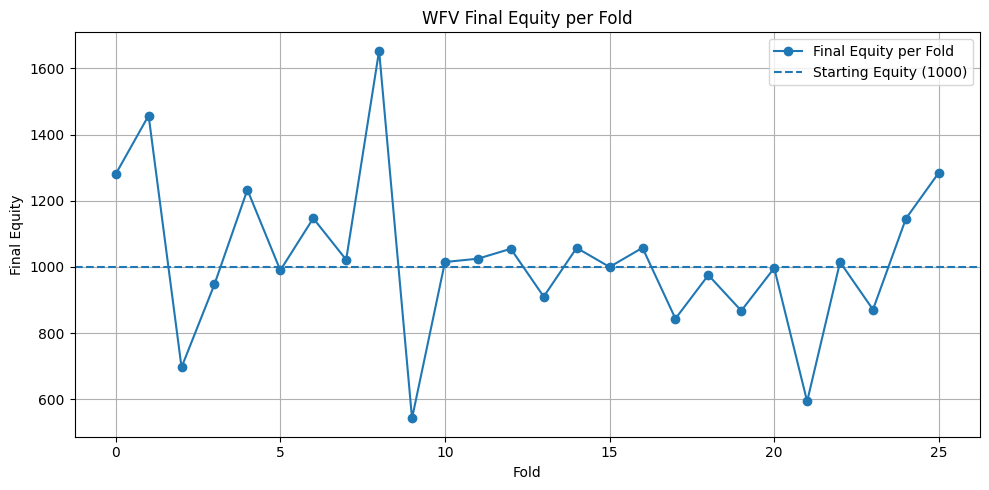

In [33]:

# Extract equities per fold
folds = [r["fold"] for r in wf_results]
equities = [r["equity"] for r in wf_results]

# Convert to numpy for convenience
folds = np.array(folds)
equities = np.array(equities)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(folds, equities, marker='o', label="Final Equity per Fold")
plt.axhline(1000.0, linestyle='--', label="Starting Equity (1000)")

plt.title("WFV Final Equity per Fold")
plt.xlabel("Fold")
plt.ylabel("Final Equity")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


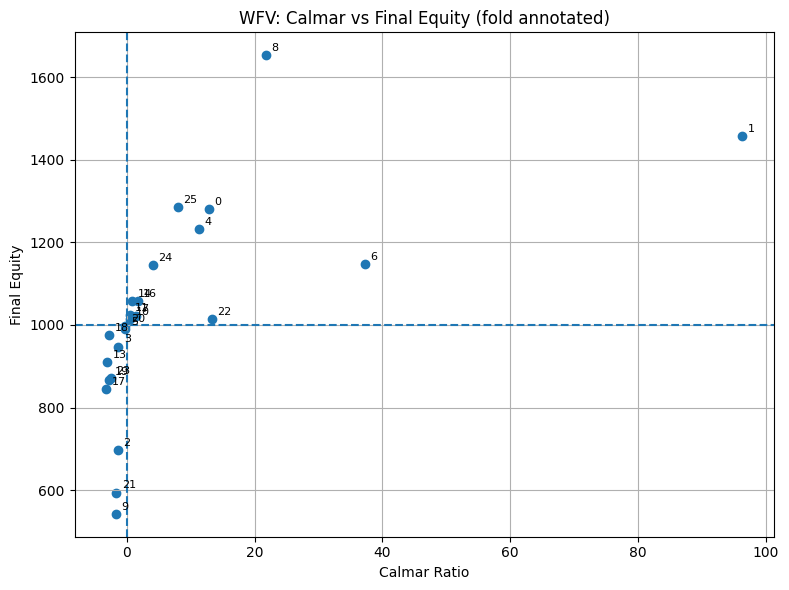

In [35]:

# --- Scatter: Calmar vs Equity ---
calmar = np.array([r["calmar"] for r in wf_results], dtype=float)
equity = np.array([r["equity"] for r in wf_results], dtype=float)
folds  = np.array([r["fold"] for r in wf_results], dtype=int)

plt.figure(figsize=(8, 6))
plt.scatter(calmar, equity)

# Label each point with its fold id
for x, y, f in zip(calmar, equity, folds):
    plt.annotate(str(f), (x, y), fontsize=8, xytext=(4, 3), textcoords="offset points")

# Reference lines
plt.axhline(1000.0, linestyle="--")  # starting equity
plt.axvline(0.0, linestyle="--")     # Calmar >= 0 is "not losing by DD-adjusted return"

plt.title("WFV: Calmar vs Final Equity (fold annotated)")
plt.xlabel("Calmar Ratio")
plt.ylabel("Final Equity")
plt.grid(True)
plt.tight_layout()
plt.show()


What you should do now

Keep running all folds

Save all models that meet rules, e.g.:

Equity > 1,100

MDD < 20%

Calmar > 3 (you’re way above this already)

Traded > 20

After WFV finishes:

Rank models by Calmar first

Then by Equity

Then by Stability (MDD, trades)

Use:

Top 3–5 models as an ensemble, or

The single best Calmar + stable trade count model